# SAM seg the buildings shapefile
After convert the shaepfile to the image, we are going to use SAM through "Transformers" to segment every block.

You can get the image from following commands

In [ ]:
'''
!conda activate sdi
!cd Load
!python rasterize.py
'''

In [1]:
import os
os.environ["TRANSFORMERS_CACHE"] = "./cache"

Show the image

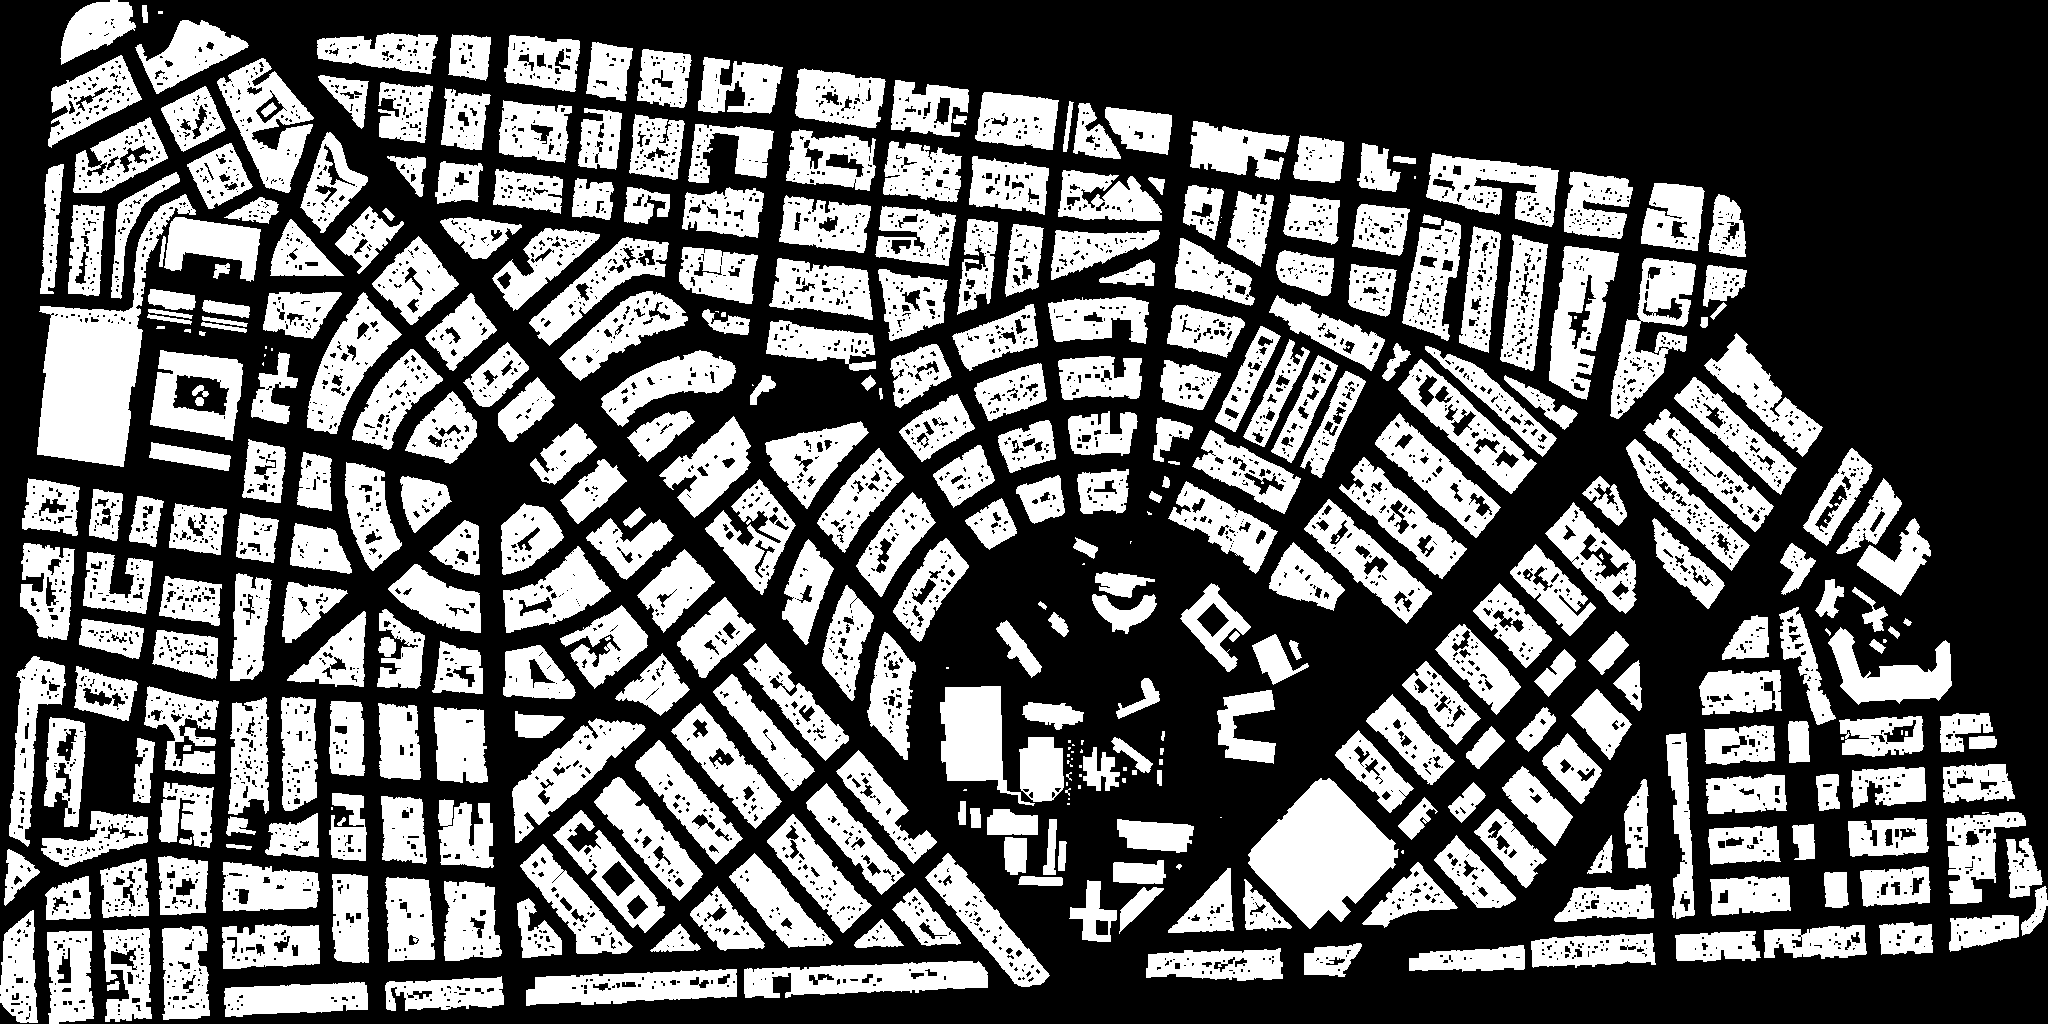

In [2]:
from PIL import Image
img = Image.open("../Load/polygons_2048_1024.png")
display(img)

### Dilate the image

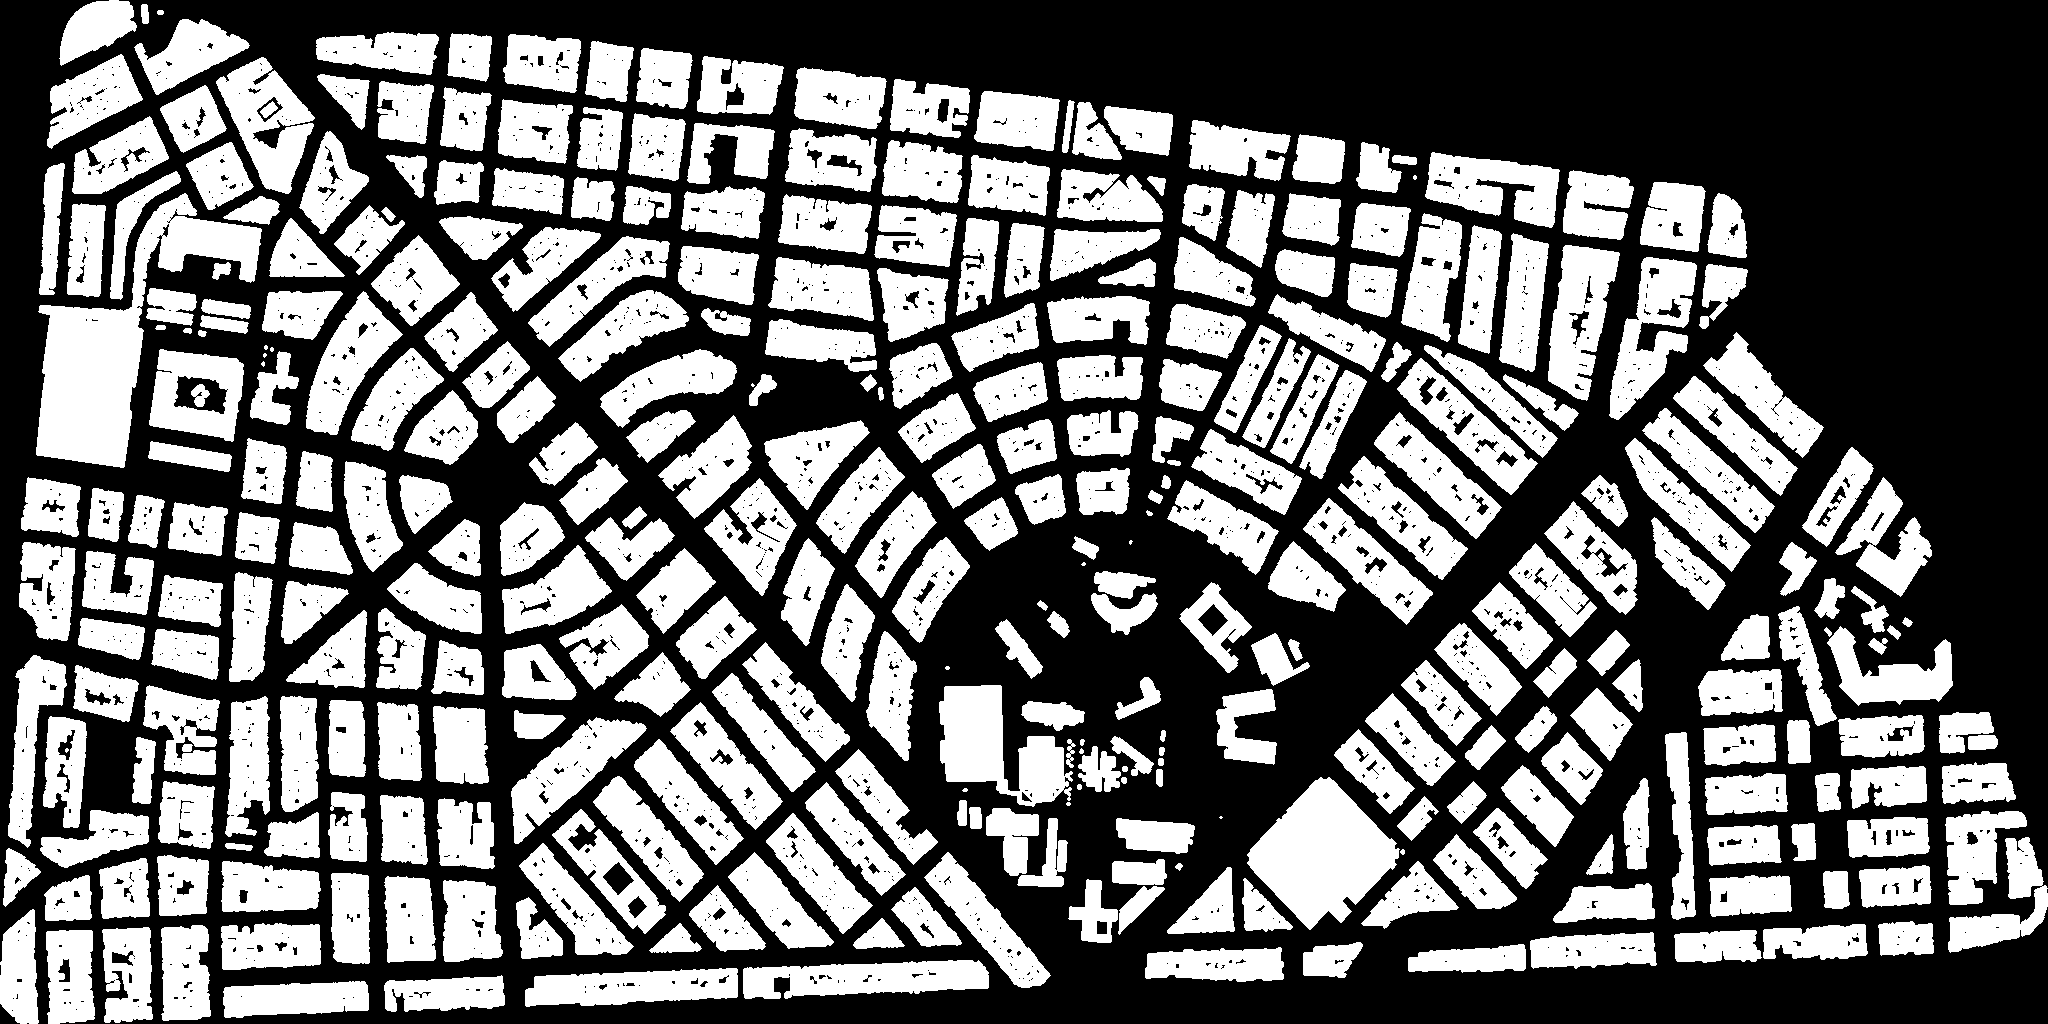

In [3]:
import numpy as np
from scipy.ndimage import binary_dilation
from skimage.morphology import disk

def dilate_pil_image(pil_image, kernel_size=3):
      """
      Apply dilation operation to PIL RGB image
      
      Args:
          pil_image: PIL Image object
          kernel_size: Size of the dilation kernel (default: 3)
      
      Returns:
          New dilated PIL Image
      """
      rgb_array = np.array(pil_image)
      binary_mask = np.any(rgb_array > 0, axis=2)
      kernel = disk(kernel_size)
      dilated_mask = binary_dilation(binary_mask, structure=kernel)
      dilated_array = np.zeros_like(rgb_array)
      dilated_array[dilated_mask] = [255, 255, 255]

      return Image.fromarray(dilated_array)



new_img = dilate_pil_image(img, kernel_size=1)
display(new_img)


## Import the SAM model

/home/ys_tum/miniconda3/envs/sdi/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


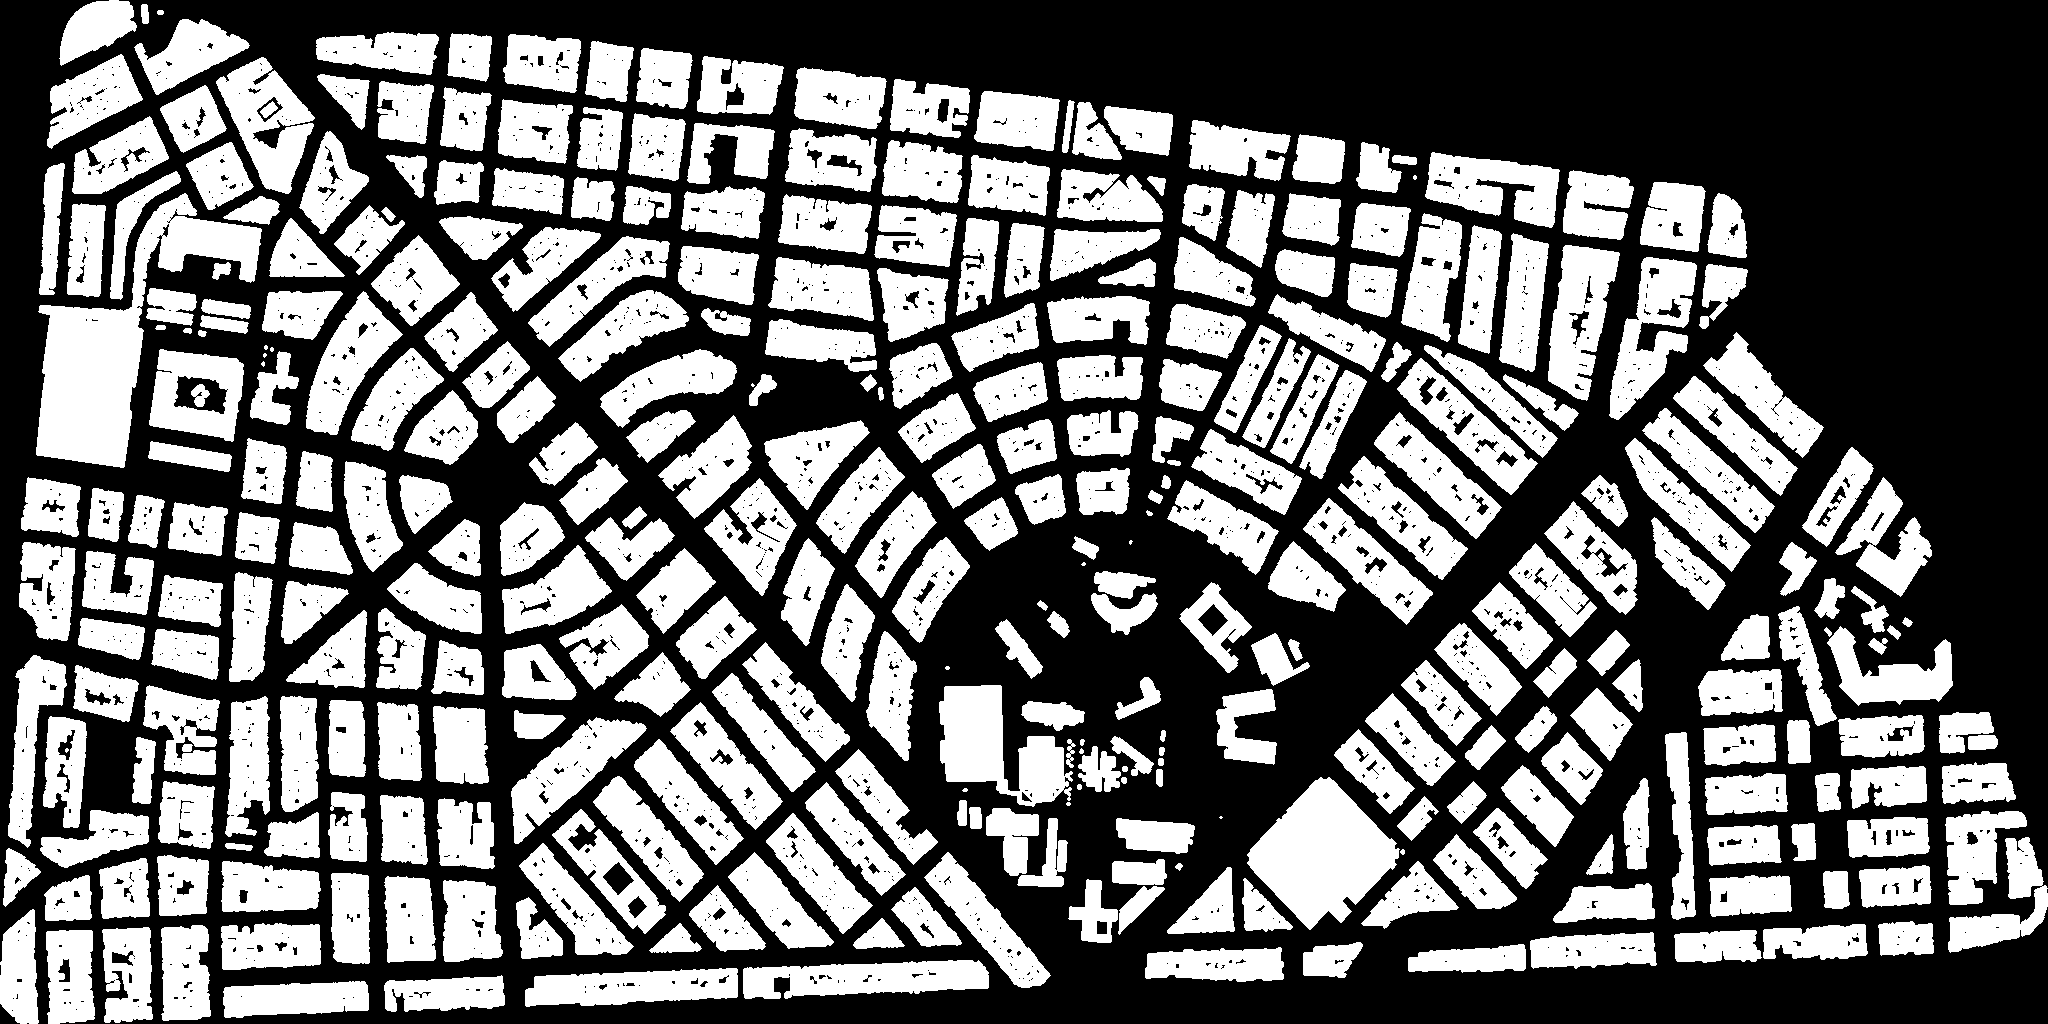

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu


'\noutputs = generator(raw_image, points_per_batch=16,\n                                pred_iou_thresh=0.4,\n                                points_per_side=256,\n                                stability_score_thresh=0.5,\n                                crop_n_layers=0,\n                                box_nms_thresh=0.3)\n'

In [4]:
from transformers import SamModel, SamProcessor
import numpy as np

raw_image = new_img.convert("RGB")
display(raw_image)
device = "cpu"

# Create a mask of non-background areas (where buildings exist)
img_array = np.array(raw_image)

from transformers import pipeline
generator = pipeline("mask-generation", model="facebook/sam-vit-base", device=device, cache_dir="./cache")
outputs = generator(raw_image, points_per_batch=32, points_per_side=256)
'''
outputs = generator(raw_image, points_per_batch=16,
                                pred_iou_thresh=0.4,
                                points_per_side=256,
                                stability_score_thresh=0.5,
                                crop_n_layers=0,
                                box_nms_thresh=0.3)
'''

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_combined_masks(masks, ax, colormap='tab20'):
    """显示单个合并掩码，背景为cluster 0"""
    if len(masks) == 0:
        return
    
    h, w = masks[0].shape[-2:]
    combined_mask = np.zeros((h, w), dtype=np.int32)  # Background starts as 0
    for i, mask in enumerate(masks, 1):  # Masks start from 1
        mask_reshaped = mask.reshape(h, w)
        combined_mask[mask_reshaped > 0.5] = i
    im = ax.imshow(combined_mask, cmap=colormap)
    return im

ax = plt.gca()
show_combined_masks(outputs["masks"], ax=ax)
plt.axis("off")
plt.show()

Save the mask results to local

In [10]:
import pickle
# Save complete outputs with metadata
with open("./mask_res/cada_masks_2048_1024.pkl", "wb") as f:
      pickle.dump(outputs, f)

Read the saved masks results

In [ ]:
import pickle
  # Load the saved outputs
with open("./mask_res/cada_masks_2048_1024.pkl", "rb") as f:
      loaded_outputs = pickle.load(f)
outputs = loaded_outputs
masks = loaded_outputs["masks"]

shape is 1024, 2048


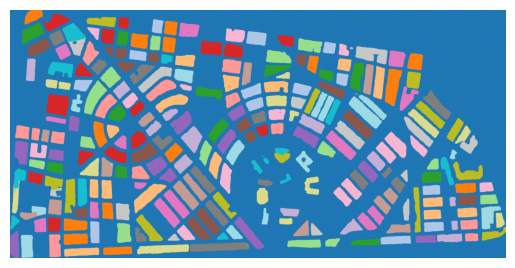

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def show_combined_masks(masks, ax, colormap='tab20'):
    """显示单个合并掩码，背景为cluster 0"""
    if len(masks) == 0:
        return
    
    h, w = masks[0].shape[-2:]
    print(f"shape is {h}, {w}")
    combined_mask = np.zeros((h, w), dtype=np.int32)  # Background starts as 0
    for i, mask in enumerate(masks, 1):  # Masks start from 1
        mask_reshaped = mask.reshape(h, w)
        combined_mask[mask_reshaped > 0.5] = i
    im = ax.imshow(combined_mask, cmap=colormap)
    return im

ax = plt.gca()
show_combined_masks(outputs["masks"], ax=ax)
plt.axis("off")
plt.show()

### background set to black

shape is 1024, 2048


/tmp/ipykernel_31774/702979606.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap(colormap)


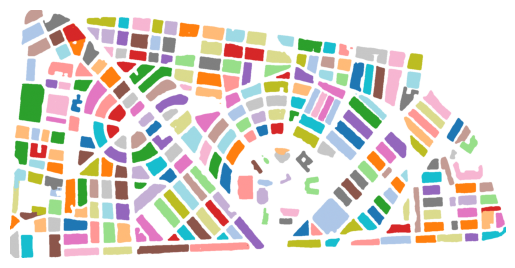

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_combined_masks(masks, ax, colormap='tab20', background_color='white'):
    """显示单个合并掩码，大背景设置为指定颜色"""
    if len(masks) == 0:
        return
        
    h, w = masks[0].shape[-2:]
    print(f"shape is {h}, {w}")
    combined_mask = np.zeros((h, w), dtype=np.int32)  # Background starts as 0
    for i, mask in enumerate(masks, 1):  # Masks start from 1
        mask_reshaped = mask.reshape(h, w)
        combined_mask[mask_reshaped > 0.5] = i

    base_cmap = plt.cm.get_cmap(colormap)
    colors = [background_color]
    
    # 添加其他颜色
    for i in range(1, len(masks) + 1):
        colors.append(base_cmap(i % base_cmap.N))
    
    custom_cmap = plt.matplotlib.colors.ListedColormap(colors)
    im = ax.imshow(combined_mask, cmap=custom_cmap, vmin=0, vmax=len(masks))
    return im

# 使用示例
ax = plt.gca()
show_combined_masks(outputs["masks"], ax=ax, background_color='white')  # 白色背景
plt.axis("off")
plt.show()

## add text promopt

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/613M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu


Found 0 potential building detections


```python
generator =  pipeline("mask-generation", device = device, points_per_batch = 256, cache_dir="./cache")                                                                
outputs = generator(raw_image, points_per_batch = 256) 
```

# Segformer

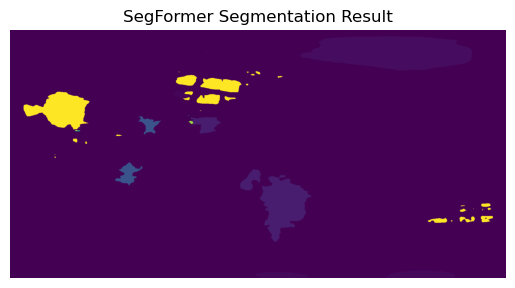

In [6]:
from transformers import SegformerFeatureExtractor, SegformerForSemanticSegmentation
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt

image = Image.open("../Load/polygons_2048_1024.png").convert("RGB")


extractor = SegformerFeatureExtractor.from_pretrained("nvidia/segformer-b5-finetuned-ade-640-640", cache_dir='./cache')
model = SegformerForSemanticSegmentation.from_pretrained("nvidia/segformer-b5-finetuned-ade-640-640", cache_dir='./cache',use_safetensors=True)
inputs = extractor(images=image, return_tensors="pt")

# 推理
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits  # [batch, num_labels, height, width]
    upsampled_logits = torch.nn.functional.interpolate(logits,
        size=image.size[::-1], mode="bilinear", align_corners=False)
    predicted = upsampled_logits.argmax(dim=1)[0].cpu().numpy()

# 可视化
plt.imshow(predicted)
plt.title("SegFormer Segmentation Result")
plt.axis("off")
plt.show()


# DeepLabv3+

In [ ]:
import torchvision
from torchvision import transforms
from PIL import Image
import torch
import matplotlib.pyplot as plt

model = torchvision.models.segmentation.deeplabv3_resnet101(pretrained=True, cache_dir = "./cache").eval()
image = Image.open("../Load/polygons_2048_1024.png").convert("RGB")
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])
input_tensor = transform(image).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)['out'][0]
    pred = output.argmax(0).cpu().numpy()

plt.imshow(pred)
plt.title("DeepLabv3+ Prediction")


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /home/ys_tum/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth
  2%|▏         | 4.50M/233M [00:00<00:19, 12.1MB/s]


KeyboardInterrupt: 

# New SAM

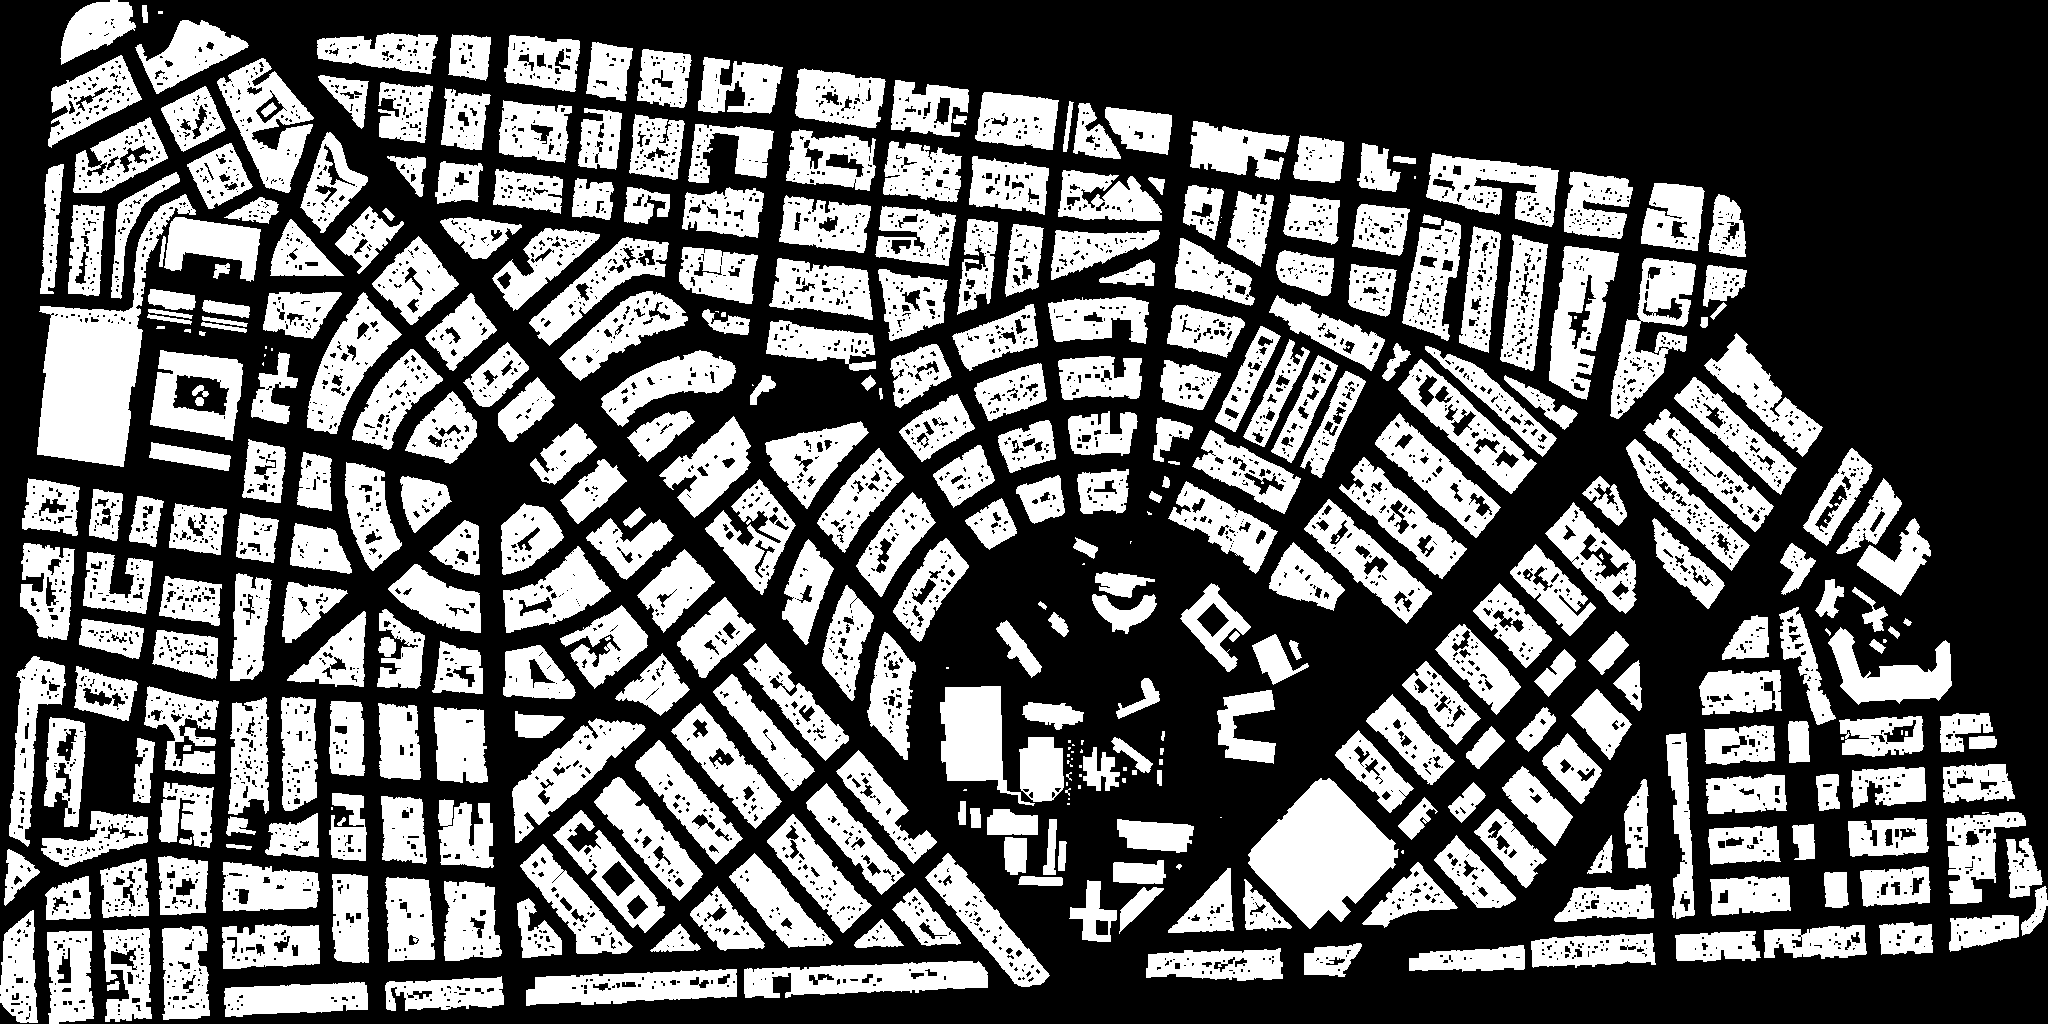

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import SamProcessor, SamModel

processor = SamProcessor.from_pretrained("facebook/sam-vit-base", cache_dir="./cache")
model = SamModel.from_pretrained("facebook/sam-vit-base", cache_dir="./cache")

image = Image.open("../Load/polygons_2048_1024.png").convert("RGB")
display(image)

inputs = processor(images=image, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)


shape is 256, 256


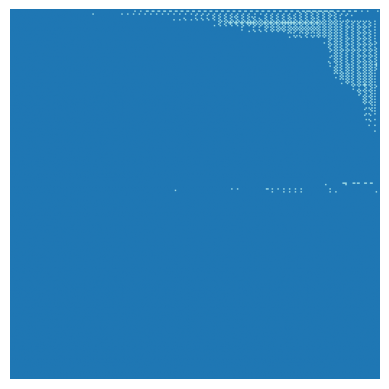

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def show_combined_masks(masks, ax, colormap='tab20'):
    """显示单个合并掩码，背景为cluster 0"""
    if len(masks) == 0:
        return
    
    h, w = masks[0].shape[-2:]
    print(f"shape is {h}, {w}")
    combined_mask = np.zeros((h, w), dtype=np.int32)  # Background starts as 0
    for i, mask in enumerate(masks, 1):  # Masks start from 1
        mask_reshaped = mask.reshape(h, w)
        combined_mask[mask_reshaped > 0.5] = i
    im = ax.imshow(combined_mask, cmap=colormap)
    return im

ax = plt.gca()
show_combined_masks(outputs.pred_masks.squeeze().cpu().numpy(), ax=ax)
plt.axis("off")
plt.show()

# Watershed

方法1: 分水岭分割
开始分水岭分割...
阈值处理完成，白色建筑物为前景
分水岭分割完成，生成 1325 个区域


/tmp/ipykernel_31774/3259655183.py:91: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31774/3259655183.py:91: UserWarning: Glyph 21106 (\N{CJK UNIFIED IDEOGRAPH-5272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31774/3259655183.py:91: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31774/3259655183.py:91: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31774/3259655183.py:91: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31774/3259655183.py:91: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31774/3259655183.py:91: UserWarning: Glyph 22495 (\N{CJK UNIFIED IDEOGRAP

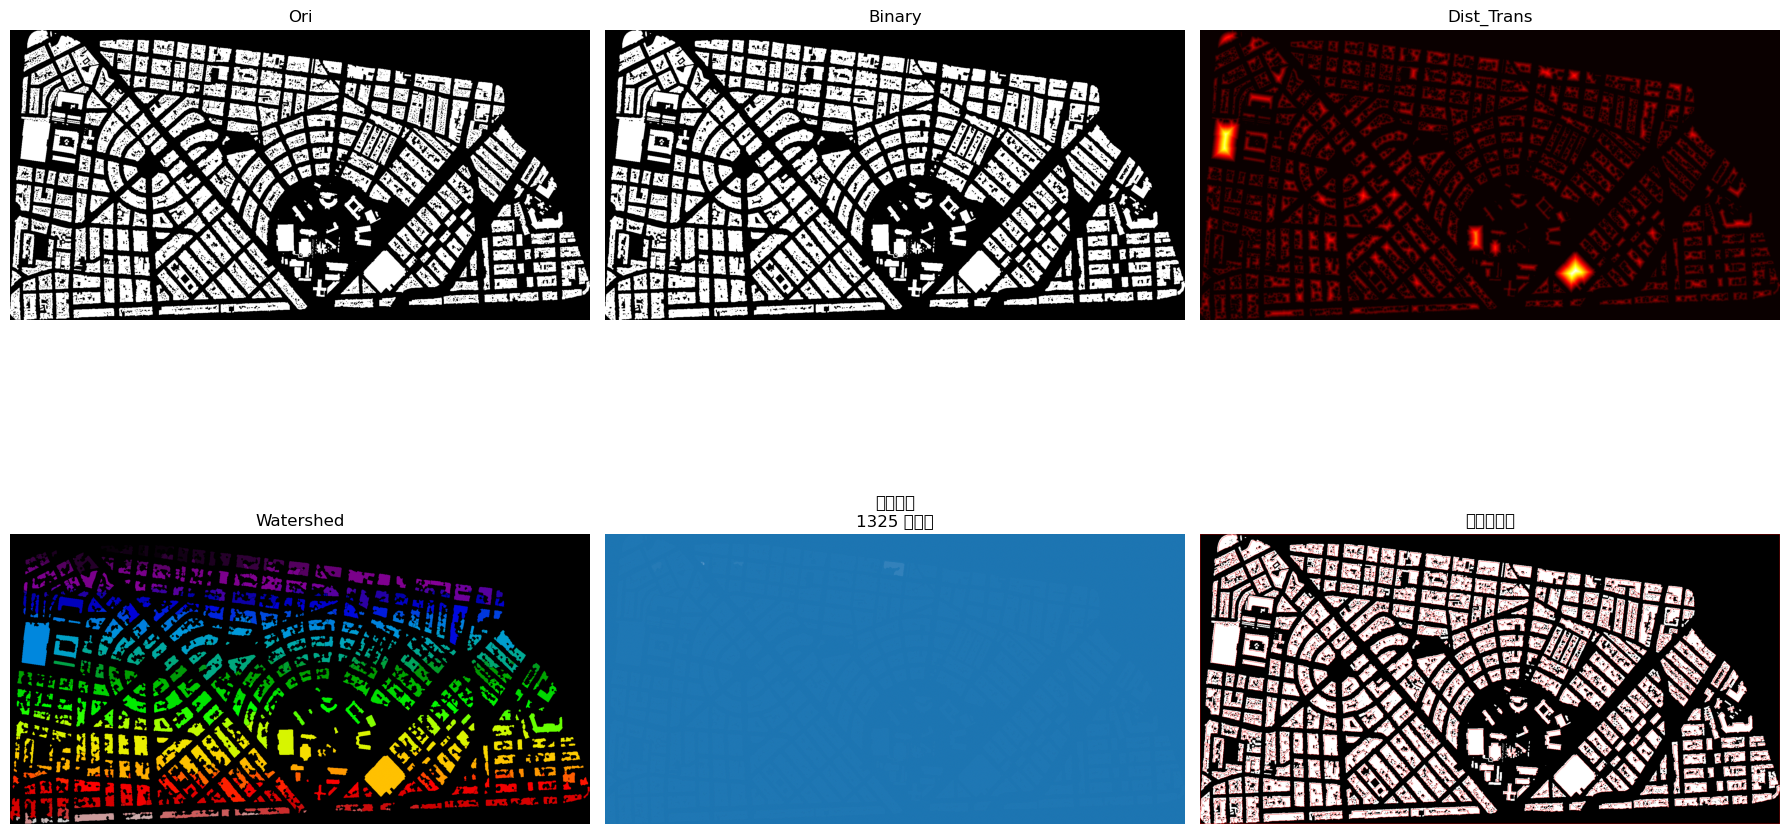


分割完成!
生成了 1325 个区域
最大区域面积: 12314
最小区域面积: 21

方法2: 建筑物优化分割
使用建筑物优化分割方法...
检测到 369 个建筑物


/tmp/ipykernel_31774/3259655183.py:142: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31774/3259655183.py:142: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31774/3259655183.py:142: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31774/3259655183.py:142: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31774/3259655183.py:142: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ys_tum/miniconda3/envs/sdi/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/y

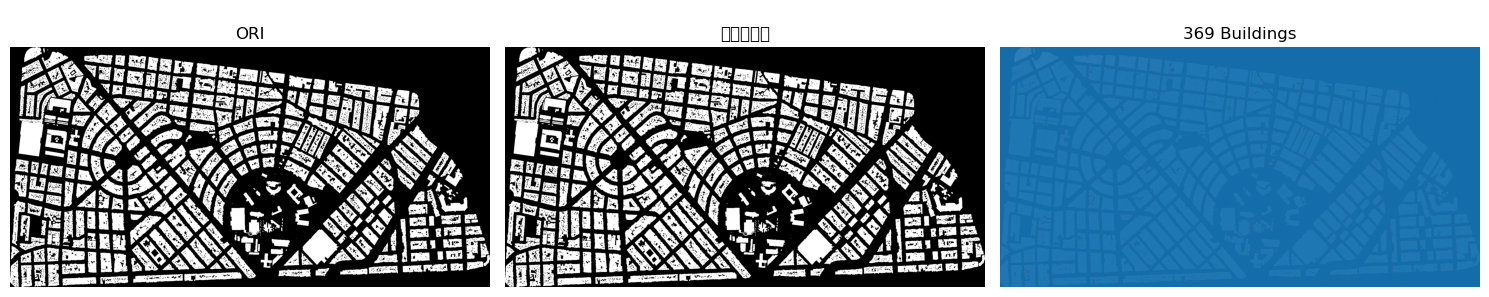

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def watershed_segmentation(image_path, min_area=20, iterations=1, dist_thresh=0.1):
    """
    纯分水岭分割方法 - 激进参数提取所有建筑块
    
    Args:
        image_path: 图像路径
        min_area: 最小区域面积，设置很小以保留所有建筑块
        iterations: 形态学操作迭代次数
        dist_thresh: 距离变换阈值，设置很小进行细分割
    """
    # 读取图像
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    
    print("开始分水岭分割...")
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, binary = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)
    print(f"阈值处理完成，白色建筑物为前景")

    kernel = np.ones((2, 2), np.uint8)
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=iterations)
    
    sure_bg = cv2.dilate(opening, kernel, iterations=1)
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, dist_thresh * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    
    # 步骤6: 确定未知区域
    unknown = cv2.subtract(sure_bg, sure_fg)
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    markers = cv2.watershed(image, markers)
    watershed_masks = []
    unique_labels = np.unique(markers)
    
    for label in unique_labels:
        if label > 1:  # 跳过背景(0,1)和边界(-1)
            mask = (markers == label)
            area = np.sum(mask)
            
            if area > min_area:  # 过滤小区域
                watershed_masks.append(mask)
    
    print(f"分水岭分割完成，生成 {len(watershed_masks)} 个区域")
    
    # 可视化结果
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 原图
    axes[0,0].imshow(image_rgb)
    axes[0,0].set_title("Ori")
    axes[0,0].axis('off')
    
    # 二值化结果
    axes[0,1].imshow(binary, cmap='gray')
    axes[0,1].set_title("Binary")
    axes[0,1].axis('off')
    
    # 距离变换
    axes[0,2].imshow(dist_transform, cmap='hot')
    axes[0,2].set_title("Dist_Trans")
    axes[0,2].axis('off')
    
    # 标记结果
    axes[1,0].imshow(markers, cmap='nipy_spectral')
    axes[1,0].set_title("Watershed")
    axes[1,0].axis('off')
    
    # 分割结果叠加 - 修复颜色错误
    axes[1,1].imshow(image_rgb)
    for i, mask in enumerate(watershed_masks[:50]):  # 显示前50个
        axes[1,1].imshow(mask, alpha=0.4, cmap='tab20', vmin=0, vmax=19)
    axes[1,1].set_title(f"分割结果\n{len(watershed_masks)} 个区域")
    axes[1,1].axis('off')
    
    # 边界显示
    boundary_img = image_rgb.copy()
    boundary_img[markers == -1] = [255, 0, 0]  # 红色边界
    axes[1,2].imshow(boundary_img)
    axes[1,2].set_title("分水岭边界")
    axes[1,2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return watershed_masks, markers

def optimized_building_segmentation(image_path):
    """
    专门针对黑色背景白色建筑物的优化分割
    """
    print("使用建筑物优化分割方法...")
    
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    
    # 对于白色建筑物，直接使用高阈值
    _, binary = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
    
    # 很小的形态学操作保持建筑物形状
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    building_masks = []
    for i, contour in enumerate(contours):
        area = cv2.contourArea(contour)
        if area > 5:  # 过滤极小区域
            mask = np.zeros(gray.shape, dtype=np.uint8)
            cv2.fillPoly(mask, [contour], 255)
            building_masks.append(mask > 0)
    
    print(f"检测到 {len(building_masks)} 个建筑物")
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(image_rgb)
    plt.title("ORI")
    plt.axis('off')
    
    plt.subplot(1, 3, 2) 
    plt.imshow(binary, cmap='gray')
    plt.title("二值化结果")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(image_rgb)
    for i, mask in enumerate(building_masks):
        plt.imshow(mask, alpha=0.1, cmap='tab20', vmin=0, vmax=19)
    plt.title(f"\n{len(building_masks)} Buildings")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return building_masks

image_path = "../Load/polygons_2048_1024.png"

print("方法1: 分水岭分割")
masks, markers = watershed_segmentation(image_path)

print(f"\n分割完成!")
print(f"生成了 {len(masks)} 个区域")
if masks:
    print(f"最大区域面积: {max([np.sum(mask) for mask in masks])}")
    print(f"最小区域面积: {min([np.sum(mask) for mask in masks])}")

print("\n" + "="*50)
print("方法2: 建筑物优化分割")
building_masks = optimized_building_segmentation(image_path)

 

In [17]:
print(type(building_masks))
print(f"shape of masks is {len(building_masks)}, {type(building_masks[0])}")
print(building_masks[0].shape)

<class 'list'>
shape of masks is 369, <class 'numpy.ndarray'>
(1024, 2048)


## Vis the building masks

shape is 1024, 2048


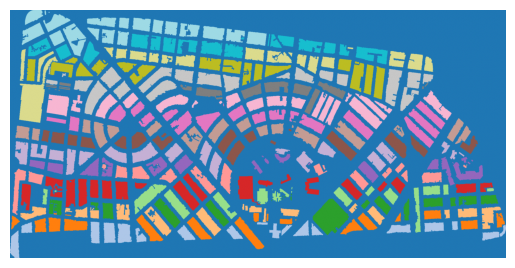

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def show_combined_masks(masks, ax, colormap='tab20'):
    """显示单个合并掩码，背景为cluster 0"""
    if len(masks) == 0:
        return
    
    h, w = masks[0].shape[-2:]
    print(f"shape is {h}, {w}")
    combined_mask = np.zeros((h, w), dtype=np.int32)  # Background starts as 0
    for i, mask in enumerate(masks, 1):  # Masks start from 1
        mask_reshaped = mask.reshape(h, w)
        combined_mask[mask_reshaped > 0.5] = i
    im = ax.imshow(combined_mask, cmap=colormap)
    return im

ax = plt.gca()
show_combined_masks(building_masks, ax=ax)
plt.axis("off")
plt.show()

shape is 1024, 2048


/tmp/ipykernel_31774/1435780678.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap(colormap)


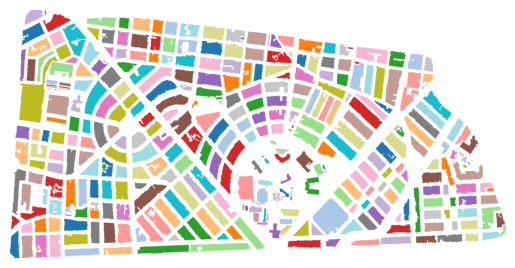

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def show_combined_masks(masks, ax, colormap='tab20', background_color='white'):
    """显示单个合并掩码，大背景设置为指定颜色"""
    if len(masks) == 0:
        return
        
    h, w = masks[0].shape[-2:]
    print(f"shape is {h}, {w}")
    combined_mask = np.zeros((h, w), dtype=np.int32)  # Background starts as 0
    for i, mask in enumerate(masks, 1):  # Masks start from 1
        mask_reshaped = mask.reshape(h, w)
        combined_mask[mask_reshaped > 0.5] = i

    base_cmap = plt.cm.get_cmap(colormap)
    colors = [background_color]
    
    # 添加其他颜色
    for i in range(1, len(masks) + 1):
        colors.append(base_cmap(i % base_cmap.N))
    
    custom_cmap = plt.matplotlib.colors.ListedColormap(colors)
    im = ax.imshow(combined_mask, cmap=custom_cmap, vmin=0, vmax=len(masks))
    return im

# 使用示例
ax = plt.gca()
show_combined_masks(building_masks, ax=ax, background_color='white')  # 白色背景
plt.axis("off")
plt.show()

In [15]:
import pickle
# Save complete outputs with metadata
with open("./mask_res/cada_watershed_2048_1024.pkl", "wb") as f:
      pickle.dump(building_masks, f)